In [ ]:
import numpy as np
import glob
import os
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
import matplotlib.dates as mdates
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D
from datetime import datetime
from datetime import timedelta
import pickle

Plot the spatial maps of average UTCI exceedance for LCZ, WSF-MB, and Geoscape - Figure 12

/scratch/pu02/mf9078/tmp/ipykernel_2695829/4104105941.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


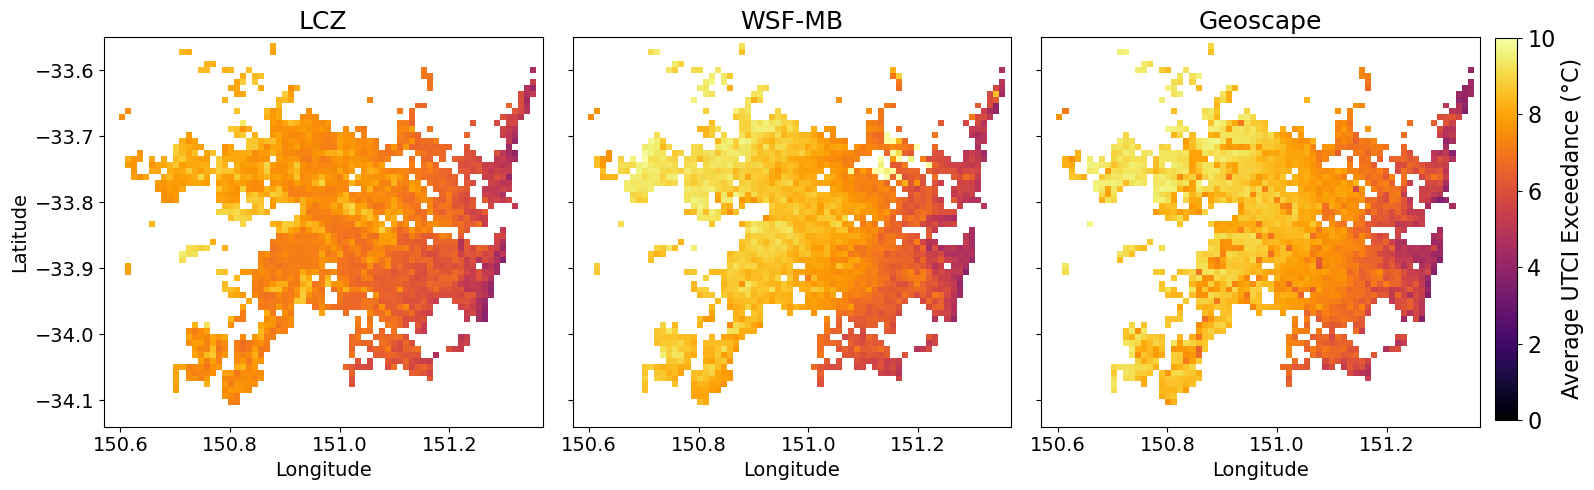

Figure saved!


In [ ]:
# Load the data
labels = ['LCZ', 'WSF-MB', 'Geoscape']
data = {}
file_luindex = "/g/data/fy29/mf9078/run_WRF/etamodified/output/4out/animation/wrfout_d02_2017-01-12_21:00:00"

# Get lat/lon coordinates from a WRF file
ds = xr.open_dataset(file_luindex)
XLAT = ds["XLAT"].squeeze()
XLONG = ds["XLONG"].squeeze()

# Load data and assign lat/lon coordinates
for label in labels:
    data[label] = xr.open_dataarray(f"/g/data/gb02/mf9078/WRF_{label}_COMF90_avg_exceedance.nc")
    data[label] = data[label].assign_coords({"south_north": XLAT.values[:, 0], 
                                              "west_east": XLONG.values[0, :]})
    data[label] = data[label].rename({"south_north": "lat", "west_east": "lon"})

# Domain limits
lat_min, lat_max = -34.14, -33.55
lon_min, lon_max = 150.57, 151.37

# Create figure with 3 subplots (shared y-axis)
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for i, label in enumerate(labels):
    # Plot without individual colorbars
    im = data[label].plot(ax=axes[i], 
                          x='lon', 
                          y='lat',
                          vmin=0, 
                          vmax=10,
                          cmap='inferno',
                          add_colorbar=False)
    axes[i].set_title(label, fontsize =18)
    axes[i].set_xlim(lon_min, lon_max)
    axes[i].set_ylim(lat_min, lat_max)
    axes[i].tick_params(axis='both', labelsize=14)  # adjust labelsize as needed
    axes[i].set_xlabel('Longitude', fontsize=14)
    if i == 0:
        axes[i].set_ylabel('Latitude', fontsize=14)
    else:
        axes[i].set_ylabel('')

# Add single colorbar on the right
cbar_ax = fig.add_axes([1, 0.15, 0.015, 0.765])
cbar = fig.colorbar(im, ax=axes, label='Average UTCI Exceedance (°C)', cax=cbar_ax) # cax=cbar_ax, , pad=0
cbar.ax.tick_params(labelsize=16)  # colorbar tick labels
cbar.set_label('Average UTCI Exceedance (°C)', fontsize=16)  # colorbar label

plt.tight_layout()
plt.savefig('/g/data/gb02/mf9078/COMF90_avg_exceedance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved!")

Calculating total and average UTCI exceedance + total exceedance hours over the domain

In [3]:
# mask
file_luindex = "/g/data/fy29/mf9078/run_WRF/etamodified/output/4out/animation/wrfout_d02_2017-01-12_21:00:00" #any wrfout with 10-category LCZ, i.e., any scenario but bulk

lat_min, lat_max = -34.14, -33.55
lon_min, lon_max = 150.57, 151.37

# Initialize on first file to get the subset bounds and mask
ds = xr.open_dataset(file_luindex) 
XLAT = ds["XLAT"]
XLONG = ds["XLONG"]
LU_INDEX = ds["LU_INDEX"]

lat_mask = (XLAT >= lat_min) & (XLAT <= lat_max)
lon_mask = (XLONG >= lon_min) & (XLONG <= lon_max)
lu_mask = (LU_INDEX >= 51) & (LU_INDEX <= 60)
region_mask = lat_mask & lon_mask & lu_mask

In [3]:
#code to extract variables of interest from LCZ, WSF3DMSB, and Geoscape cases

# Constants
#Rd = 287.05  # J/kg/K

vars = ['COMF90', 'COMF10']
stats = ['exceedance', 'exceeded hour']

# file paths
paths = {
    "LCZ": "/g/data/fy29/mf9078/run_WRF/etamodified/output/1out/animation/",
    "WSF-MB": "/g/data/fy29/mf9078/run_WRF/etamodified/output/3out/animation/",
    "Geoscape": "/g/data/fy29/mf9078/run_WRF/etamodified/output/4out/animation/"
}

# Dictionary to store results for each scenario, period, and variable
results = {}
results['time']=[]
for label, sc_path in paths.items():
    results[label] = {}
    for var in vars:
        results[label][var]={}
        for stat in stats:
            results[label][var][stat]=[]

# Loop through all the scenarios
for label, sc_path in paths.items():
    file_list = sorted(glob.glob(os.path.join(sc_path, "wrfout_d02_2017-01-*")))
      
    # Loop through files
    for fpath in file_list:
        ds = xr.open_dataset(fpath)
        
        # Parse timestamp and convert to AEST
        timestamp_utc = datetime.strptime(os.path.basename(fpath)[11:], "%Y-%m-%d_%H:%M:%S")
        timestamp_aest = timestamp_utc + timedelta(hours=10)
                    
        variables = {
            'COMF90': ds["COMF_90"].where(region_mask), 
            'COMF10': ds["COMF_10"].where(region_mask),
        }
                
        if label == 'LCZ': #just for one case
            results['time'].append(timestamp_aest)
        for key, val in variables.items():
            val_modified = xr.where(val > 26, val - 26, 0) #where UTCI > 26, calculate UTCI - 26, otherwise put 0
            exceededhour = xr.where(val > 26, 1, 0) #where UTCI > 26, put 1, otherwise put 0
            results[label][key]['exceedance'].append(val_modified)
            results[label][key]['exceeded hour'].append(exceededhour)

with open("/g/data/gb02/mf9078/WRF_UTCI_exceedance.pkl", "wb") as f:
    pickle.dump(results, f)

In [ ]:
#calcualte average exceedance ans save as netCDF files
with open("/g/data/gb02/mf9078/WRF_UTCI_exceedance.pkl", "rb") as f:
    results=pickle.load(f)

# Dictionary to store the final results
final_results = {}

# Loop through each label (LCZ, WSF-MB, Geoscape)
for label in ['LCZ', 'WSF-MB', 'Geoscape']:
    final_results[label] = {}
    
    # Loop through each variable (COMF90, COMF10)
    for key in ['COMF90', 'COMF10']:
        final_results[label][key] = {}
        
        # 1. Sum all exceedance values
        exceedance_sum = sum(results[label][key]['exceedance'])
        final_results[label][key]['total_exceedance'] = exceedance_sum
        
        # 2. Sum all exceeded hour values
        exceeded_hour_sum = sum(results[label][key]['exceeded hour'])
        final_results[label][key]['total_exceeded_hours'] = exceeded_hour_sum
        
        # 3. Divide total exceedance by total exceeded hours
        # Use xarray's where to avoid division by zero
        avg_exceedance = xr.where(
            exceeded_hour_sum > 0, 
            exceedance_sum / exceeded_hour_sum, 
            0
        )
        final_results[label][key]['avg_exceedance'] = avg_exceedance.where(region_mask)

# Save the results
with open("/g/data/gb02/mf9078/WRF_UTCI_exceedance_summary.pkl", "wb") as f:
    pickle.dump(final_results, f)

print("Processing complete!")

# Optional: Save individual components as NetCDF files for easier inspection
for label in ['LCZ', 'WSF-MB', 'Geoscape']:
    for key in ['COMF90', 'COMF10']:
        # Save total exceedance
        final_results[label][key]['total_exceedance'].to_netcdf(
            f"/g/data/gb02/mf9078/WRF_{label}_{key}_total_exceedance.nc"
        )
        
        # Save total exceeded hours
        final_results[label][key]['total_exceeded_hours'].to_netcdf(
            f"/g/data/gb02/mf9078/WRF_{label}_{key}_total_exceeded_hours.nc"
        )
        
        # Save average exceedance
        final_results[label][key]['avg_exceedance'].to_netcdf(
            f"/g/data/gb02/mf9078/WRF_{label}_{key}_avg_exceedance.nc"
        )

print("NetCDF files saved!")

Processing complete!
NetCDF files saved!


Spatial average of average exceedance for each experiment

In [ ]:
# Dictionary to store spatial averages
spatial_averages = {}

# Loop through each label (LCZ, WSF-MB, Geoscape)
for label in ['LCZ', 'WSF-MB', 'Geoscape']:
    spatial_averages[label] = {}
    
    # Loop through each variable (COMF90, COMF10)
    for key in ['COMF90', 'COMF10']:
        # Calculate spatial mean (ignoring NaN values from the mask)
        avg_exceedance = final_results[label][key]['avg_exceedance']
        spatial_mean = avg_exceedance.mean(skipna=True).values
        
        spatial_averages[label][key] = spatial_mean
        
        print(f"{label} - {key}: {spatial_mean:.3f}")

# Also save to file
with open("/g/data/gb02/mf9078/WRF_UTCI_spatial_averages.pkl", "wb") as f:
    pickle.dump(spatial_averages, f)

LCZ - COMF90: 7.102
LCZ - COMF10: 5.421
WSF-MB - COMF90: 7.698
WSF-MB - COMF10: 5.427
Geoscape - COMF90: 7.642
Geoscape - COMF10: 5.402
